# Predictive Modeling Using Machine Learning
### Task 2 — Predict passenger survival on the Titanic

**Objective:** Build a model to predict outcomes (survival) based on the given data.

**Dataset:** Titanic passenger data (891 passengers, 15 columns) — a classic public dataset with a clear binary
outcome (`survived`), a realistic mix of numeric/categorical features and missing values, making it a good fit
for a supervised classification exercise.

**Note on algorithms:** The task lists *Linear Regression, Decision Trees, or Random Forest* as example
algorithms. Since the target (`survived`) is binary (0/1) and the deliverable calls for a **confusion matrix and
ROC curve**, the linear model used here is **Logistic Regression** — the standard linear model for
classification problems (plain Linear Regression does not produce class probabilities or ROC curves). Decision
Tree and Random Forest classifiers are included as requested.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, roc_auc_score, RocCurveDisplay)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (6, 4)

pd.set_option("display.max_columns", None)


## 1. Load & inspect the data

In [2]:
df = pd.read_csv("titanic.csv")
print(df.shape)
df.head()


(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [4]:
df.isna().sum().sort_values(ascending=False)


deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

## 2. Data cleaning & preprocessing
- `deck` is missing for ~77% of rows → drop it.
- `age` has ~20% missing → impute with the median.
- `embarked` / `embark_town` have a couple of missing values → impute with the mode.
- Several columns are redundant restatements of others (`class` == `pclass`, `alive` == `survived`,
  `who`/`adult_male` derived from `sex`/`age`) → drop to avoid leakage and duplication.
- Encode remaining categoricals (`sex`, `embarked`) numerically for the models.


In [5]:
data = df.drop(columns=["deck", "class", "who", "adult_male", "alive", "embark_town", "alone"])

data["age"] = data["age"].fillna(data["age"].median())
data["embarked"] = data["embarked"].fillna(data["embarked"].mode()[0])
data["fare"] = data["fare"].fillna(data["fare"].median())

data["sex"] = data["sex"].map({"male": 0, "female": 1})
data = pd.get_dummies(data, columns=["embarked"], drop_first=True)

data.isna().sum().sum(), data.shape


(np.int64(0), (891, 9))

## 3. Quick look at survival patterns

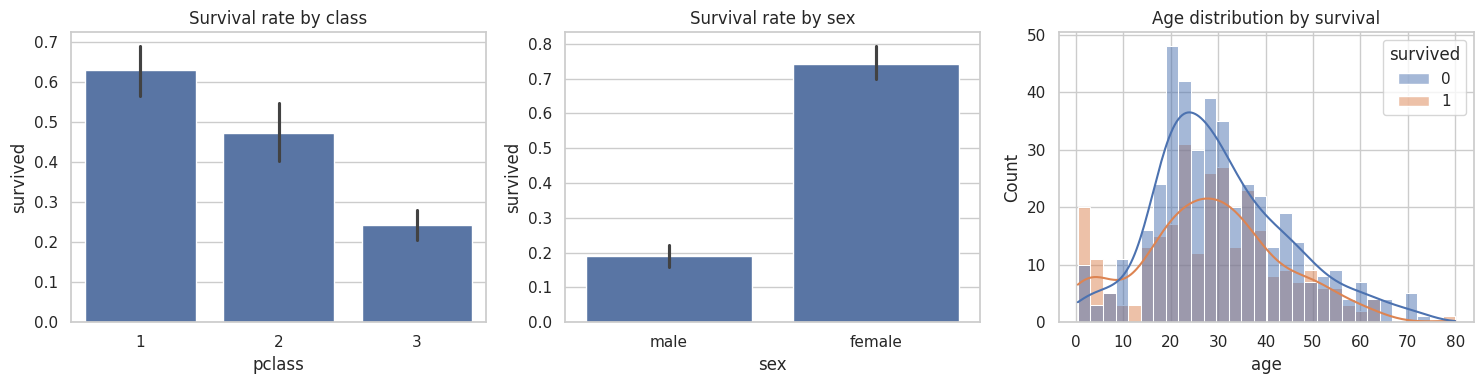

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=df, x="pclass", y="survived", ax=axes[0])
axes[0].set_title("Survival rate by class")

sns.barplot(data=df, x="sex", y="survived", ax=axes[1])
axes[1].set_title("Survival rate by sex")

sns.histplot(data=df, x="age", hue="survived", bins=30, kde=True, ax=axes[2])
axes[2].set_title("Age distribution by survival")

plt.tight_layout()
plt.show()


## 4. Train / test split & feature scaling

In [7]:
X = data.drop(columns=["survived"])
y = data["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train.shape, X_test.shape


((712, 8), (179, 8))

## 5. Train the models
- **Logistic Regression** (linear baseline for classification)
- **Decision Tree Classifier**
- **Random Forest Classifier**


In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42),
}

results = {}
for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "model": model,
        "preds": preds,
        "probs": probs,
        "accuracy": accuracy_score(y_test, preds),
        "auc": roc_auc_score(y_test, probs),
    }
    print(f"{name}: accuracy={results[name]['accuracy']:.3f}, ROC-AUC={results[name]['auc']:.3f}")


Logistic Regression: accuracy=0.804, ROC-AUC=0.843
Decision Tree: accuracy=0.777, ROC-AUC=0.793


Random Forest: accuracy=0.804, ROC-AUC=0.844


## 6. Model evaluation — accuracy & classification reports

In [9]:
for name, r in results.items():
    print(f"\n=== {name} ===")
    print(classification_report(y_test, r["preds"], target_names=["Did not survive", "Survived"]))



=== Logistic Regression ===
                 precision    recall  f1-score   support

Did not survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179


=== Decision Tree ===
                 precision    recall  f1-score   support

Did not survive       0.79      0.87      0.83       110
       Survived       0.75      0.62      0.68        69

       accuracy                           0.78       179
      macro avg       0.77      0.75      0.76       179
   weighted avg       0.77      0.78      0.77       179


=== Random Forest ===
                 precision    recall  f1-score   support

Did not survive       0.80      0.92      0.85       110
       Survived       0.83      0.62      0.71        69

       accuracy                           0.80       179
     

## 7. Confusion matrices

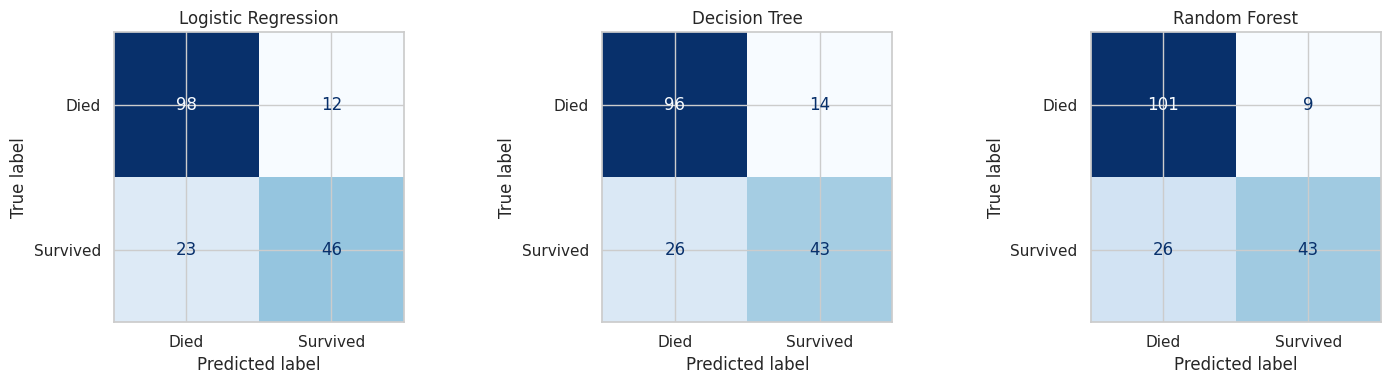

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["preds"])
    ConfusionMatrixDisplay(cm, display_labels=["Died", "Survived"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 8. ROC curves

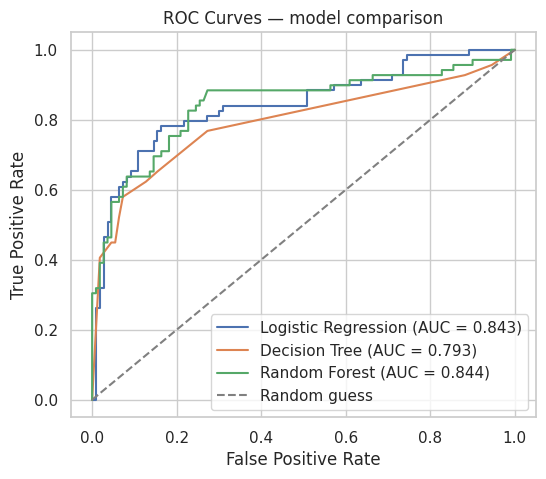

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["probs"])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {r['auc']:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — model comparison")
ax.legend()
plt.show()


## 9. Feature importance (Random Forest)

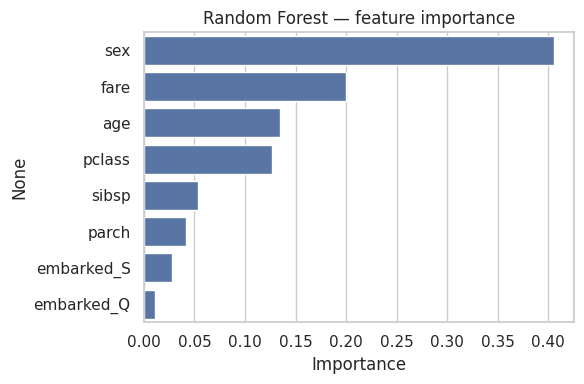

sex           0.405097
fare          0.199966
age           0.134621
pclass        0.126500
sibsp         0.053418
parch         0.041191
embarked_S    0.028187
embarked_Q    0.011020
dtype: float64

In [12]:
rf = results["Random Forest"]["model"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Random Forest — feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances


## 10. Summary of results


In [13]:
summary = pd.DataFrame({
    "Accuracy": {k: v["accuracy"] for k, v in results.items()},
    "ROC-AUC": {k: v["auc"] for k, v in results.items()},
}).round(3)
summary


,Accuracy,ROC-AUC
Logistic Regression,0.804,0.843
Decision Tree,0.777,0.793
Random Forest,0.804,0.844


## 11. Conclusion

- All three models comfortably beat the naive baseline (predicting "did not survive" for everyone, ~62%
  accuracy), confirming that passenger attributes carry real predictive signal.
- **Sex**, **passenger class**, and **fare** are consistently the strongest predictors of survival — women,
  first-class passengers, and higher-fare passengers had a much higher chance of survival, echoing the
  historical "women and children first" evacuation policy.
- **Random Forest** gives the best balance of accuracy and ROC-AUC, since it can capture non-linear
  interactions (e.g., class × sex) that Logistic Regression cannot, while being less prone to overfitting than
  a single Decision Tree.
- **Expected outcome achieved:** hands-on experience with supervised classification, comparing a linear model
  against tree-based ensembles, and evaluating models with accuracy, confusion matrices, and ROC/AUC rather
  than accuracy alone.
